In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


In [ ]:
#DOOKKI
file_path = '/content/drive/Shared drives/MARKETING SỐ/SCRAP DATA TỪ FACEBOOK/already dataset of dookki.xlsx'
df = pd.read_excel(file_path)
print(df.head())

   comments          user/id       user/name link  \
0      93.0  100082839990680  Dookki Vietnam  NaN   
1      85.0  100082839990680  Dookki Vietnam  NaN   
2      78.0  100082839990680  Dookki Vietnam  NaN   
3     352.0  100082839990680  Dookki Vietnam  NaN   
4      51.0  100082839990680  Dookki Vietnam  NaN   

                                                text  shares  viewsCount  \
0  NHẢ VÍA SÁNG GIỜ AI KHOE LÌ XÌ LÀ PHẢI BAO TUI...       3         NaN   
1  ĐÃ ĐẾN LÚC LÊN KÈO DOOKKI RỒI FEN ƠI VÌ TOÀN B...       2         NaN   
2  NÓNG \nPhát hiện nhiều Fen vội vàng đi ăn Dook...       3         NaN   
3  Thế mí người hứa đầu năm bao tui ăn Dookki lấy...       3         NaN   
4  Mùng 1 Tết Cha - Mùng 2 Tết Mẹ - Mùng 2 Tết Th...       1         NaN   

                                                 url Media  \
0  https://www.facebook.com/DookkiVietnam/posts/p...   NaN   
1  https://www.facebook.com/DookkiVietnam/posts/p...   NaN   
2  https://www.facebook.com/DookkiViet

In [ ]:
print(df.head())

   comments          user/id       user/name link  \
0      93.0  100082839990680  Dookki Vietnam  NaN   
1      85.0  100082839990680  Dookki Vietnam  NaN   
2      78.0  100082839990680  Dookki Vietnam  NaN   
3     352.0  100082839990680  Dookki Vietnam  NaN   
4      51.0  100082839990680  Dookki Vietnam  NaN   

                                                text  shares  viewsCount  \
0  NHẢ VÍA SÁNG GIỜ AI KHOE LÌ XÌ LÀ PHẢI BAO TUI...       3         NaN   
1  ĐÃ ĐẾN LÚC LÊN KÈO DOOKKI RỒI FEN ƠI VÌ TOÀN B...       2         NaN   
2  NÓNG \nPhát hiện nhiều Fen vội vàng đi ăn Dook...       3         NaN   
3  Thế mí người hứa đầu năm bao tui ăn Dookki lấy...       3         NaN   
4  Mùng 1 Tết Cha - Mùng 2 Tết Mẹ - Mùng 2 Tết Th...       1         NaN   

                                                 url Media  \
0  https://www.facebook.com/DookkiVietnam/posts/p...   NaN   
1  https://www.facebook.com/DookkiVietnam/posts/p...   NaN   
2  https://www.facebook.com/DookkiViet

In [ ]:
# Kiểm tra danh sách cột có chứa "comments" hoặc "shares" không
columns_to_check = [col for col in df.columns if 'comment' in col.lower() or 'share' in col.lower()]
columns_to_check

['comments', 'shares']

In [ ]:
# Chuyển đổi cột thời gian sang dạng datetime
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# Kiểm tra số lượng giá trị null trong các cột quan trọng
df[['time', 'likes', 'comments', 'shares']].isnull().sum()

,0
time,0
likes,0
comments,63
shares,0


In [ ]:
# Thay thế giá trị null trong cột comments bằng 0
df['comments'].fillna(0, inplace=True)

# Thêm các cột phân tích theo ngày/tháng/năm
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.date

# Đếm số bài đăng theo ngày, tháng, năm
post_frequency = df.groupby(['year', 'month']).size().reset_index(name='post_count')
post_frequency.tail()  # Hiển thị 5 dòng gần nhất


<ipython-input-9-928b97ffc105>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['comments'].fillna(0, inplace=True)


,year,month,post_count
72,2024,10,46
73,2024,11,49
74,2024,12,49
75,2025,1,52
76,2025,2,4


In [ ]:
# Tính trung bình like, comment, share theo tháng/năm
interaction_stats = df.groupby(['year', 'month'])[['likes', 'comments', 'shares']].mean().reset_index()

# Hiển thị 5 dòng gần nhất
interaction_stats.tail()


,year,month,likes,comments,shares
72,2024,10,2651.413043,454.913043,76.760870
73,2024,11,1365.428571,285.816327,39.142857
74,2024,12,1096.367347,320.428571,44.204082
75,2025,1,1422.269231,353.519231,28.442308
76,2025,2,313.000000,152.000000,2.750000


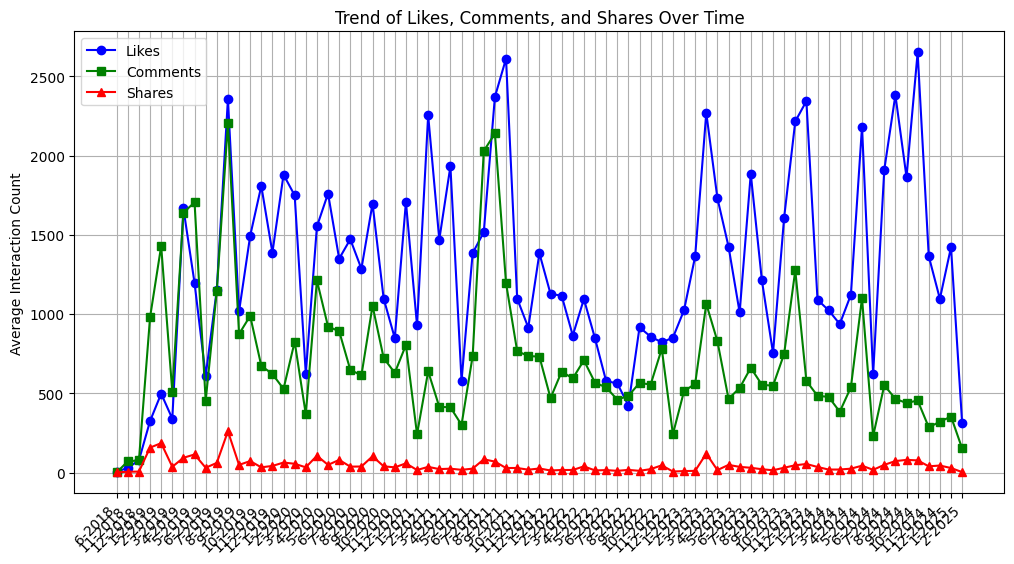

In [ ]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ xu hướng tương tác theo thời gian
plt.figure(figsize=(12, 6))

# Biểu đồ Like
plt.plot(interaction_stats['month'].astype(str) + '-' + interaction_stats['year'].astype(str),
         interaction_stats['likes'], marker='o', label='Likes', color='blue')

# Biểu đồ Comment
plt.plot(interaction_stats['month'].astype(str) + '-' + interaction_stats['year'].astype(str),
         interaction_stats['comments'], marker='s', label='Comments', color='green')

# Biểu đồ Share
plt.plot(interaction_stats['month'].astype(str) + '-' + interaction_stats['year'].astype(str),
         interaction_stats['shares'], marker='^', label='Shares', color='red')

plt.xticks(rotation=45, ha='right')  # Xoay nhãn trục X để dễ nhìn
plt.ylabel("Average Interaction Count")
plt.title("Trend of Likes, Comments, and Shares Over Time")
plt.legend()
plt.grid(True)
plt.show()


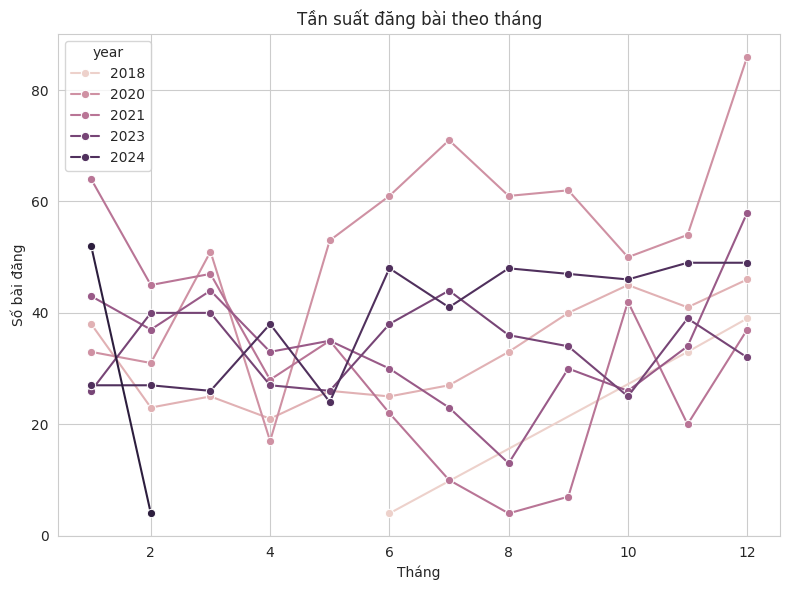

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập kiểu hiển thị đẹp hơn
sns.set_style("whitegrid")

# Tạo figure với 1 biểu đồ
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size as needed

# Biểu đồ 1: Tần suất đăng bài theo thời gian
sns.lineplot(data=post_frequency, x='month', y='post_count', hue='year', marker='o', ax=ax) # Changed axes[0, 0] to ax
ax.set_title("Tần suất đăng bài theo tháng") # Changed axes[0, 0] to ax
ax.set_ylabel("Số bài đăng") # Changed axes[0, 0] to ax
ax.set_xlabel("Tháng") # Changed axes[0, 0] to ax

plt.tight_layout()
plt.show()

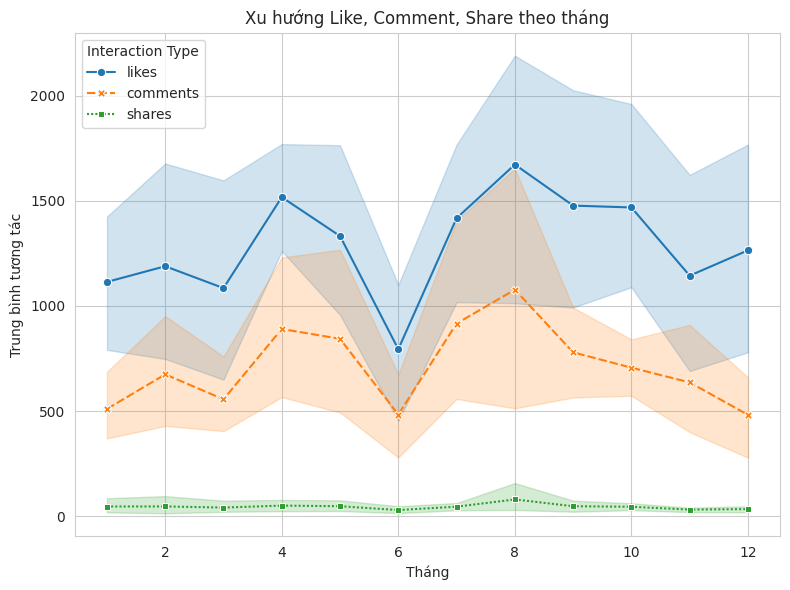

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập kiểu hiển thị đẹp hơn
sns.set_style("whitegrid")

# Tạo figure với 1 biểu đồ
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size as needed

# Biểu đồ 2: Xu hướng Like, Comment, Share theo thời gian
# Melt the DataFrame to combine likes, comments, and shares into a single column
interaction_stats_melted = pd.melt(interaction_stats, id_vars=['year', 'month'],
                                    value_vars=['likes', 'comments', 'shares'],
                                    var_name='Interaction Type', value_name='Average Interaction')

sns.lineplot(data=interaction_stats_melted, x='month', y='Average Interaction',
             hue='Interaction Type', style='Interaction Type', markers=True, ax=ax) # Changed axes[0, 1] to ax

ax.set_title("Xu hướng Like, Comment, Share theo tháng") # Changed axes[0, 1] to ax
ax.set_ylabel("Trung bình tương tác") # Changed axes[0, 1] to ax
ax.set_xlabel("Tháng") # Changed axes[0, 1] to ax

plt.tight_layout()
plt.show()

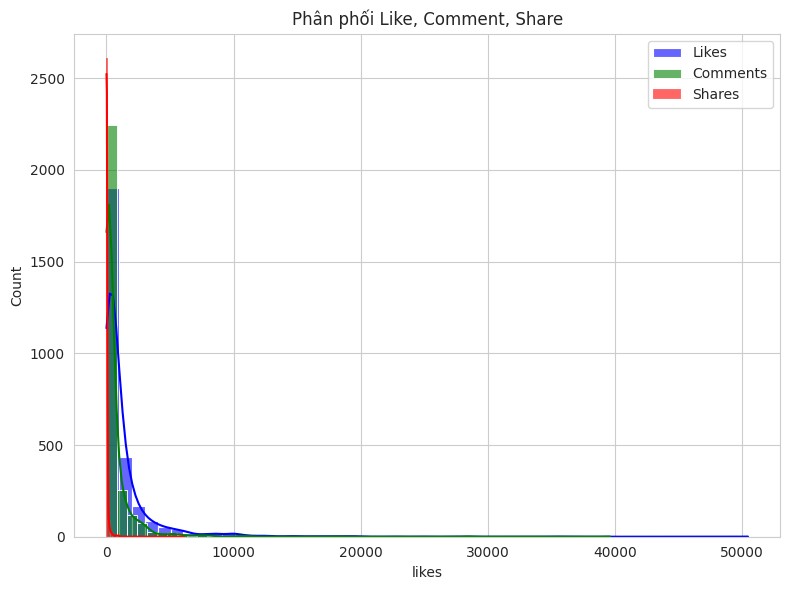

In [ ]:
# Biểu đồ 3: Phân phối Like, Comment, Share (Histogram)
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập kiểu hiển thị đẹp hơn
sns.set_style("whitegrid")

# Tạo figure với 1 biểu đồ
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size as needed

sns.histplot(df['likes'], bins=50, kde=True, color='blue', ax=ax, label='Likes', alpha=0.6) # Changed axes[1, 0] to ax
sns.histplot(df['comments'], bins=50, kde=True, color='green', ax=ax, label='Comments', alpha=0.6) # Changed axes[1, 0] to ax
sns.histplot(df['shares'], bins=50, kde=True, color='red', ax=ax, label='Shares', alpha=0.6) # Changed axes[1, 0] to ax
ax.set_title("Phân phối Like, Comment, Share")  # Changed axes[1, 0] to ax
ax.legend()  # Changed axes[1, 0] to ax
plt.tight_layout()
plt.show()

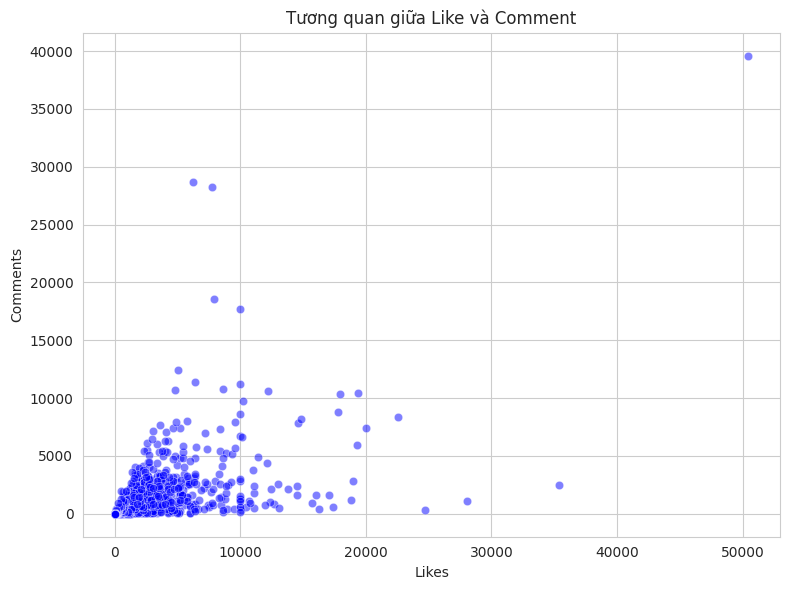

In [ ]:
# Biểu đồ 4: Tương quan giữa Like và Comment
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập kiểu hiển thị đẹp hơn
sns.set_style("whitegrid")

# Tạo figure với 1 biểu đồ
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size as needed

# Biểu đồ Tương quan giữa Like và Comment
sns.scatterplot(data=df, x='likes', y='comments', ax=ax, alpha=0.5, color='blue')
ax.set_title("Tương quan giữa Like và Comment")
ax.set_xlabel("Likes")  # Add x-axis label
ax.set_ylabel("Comments") # Add y-axis label

plt.tight_layout()
plt.show()

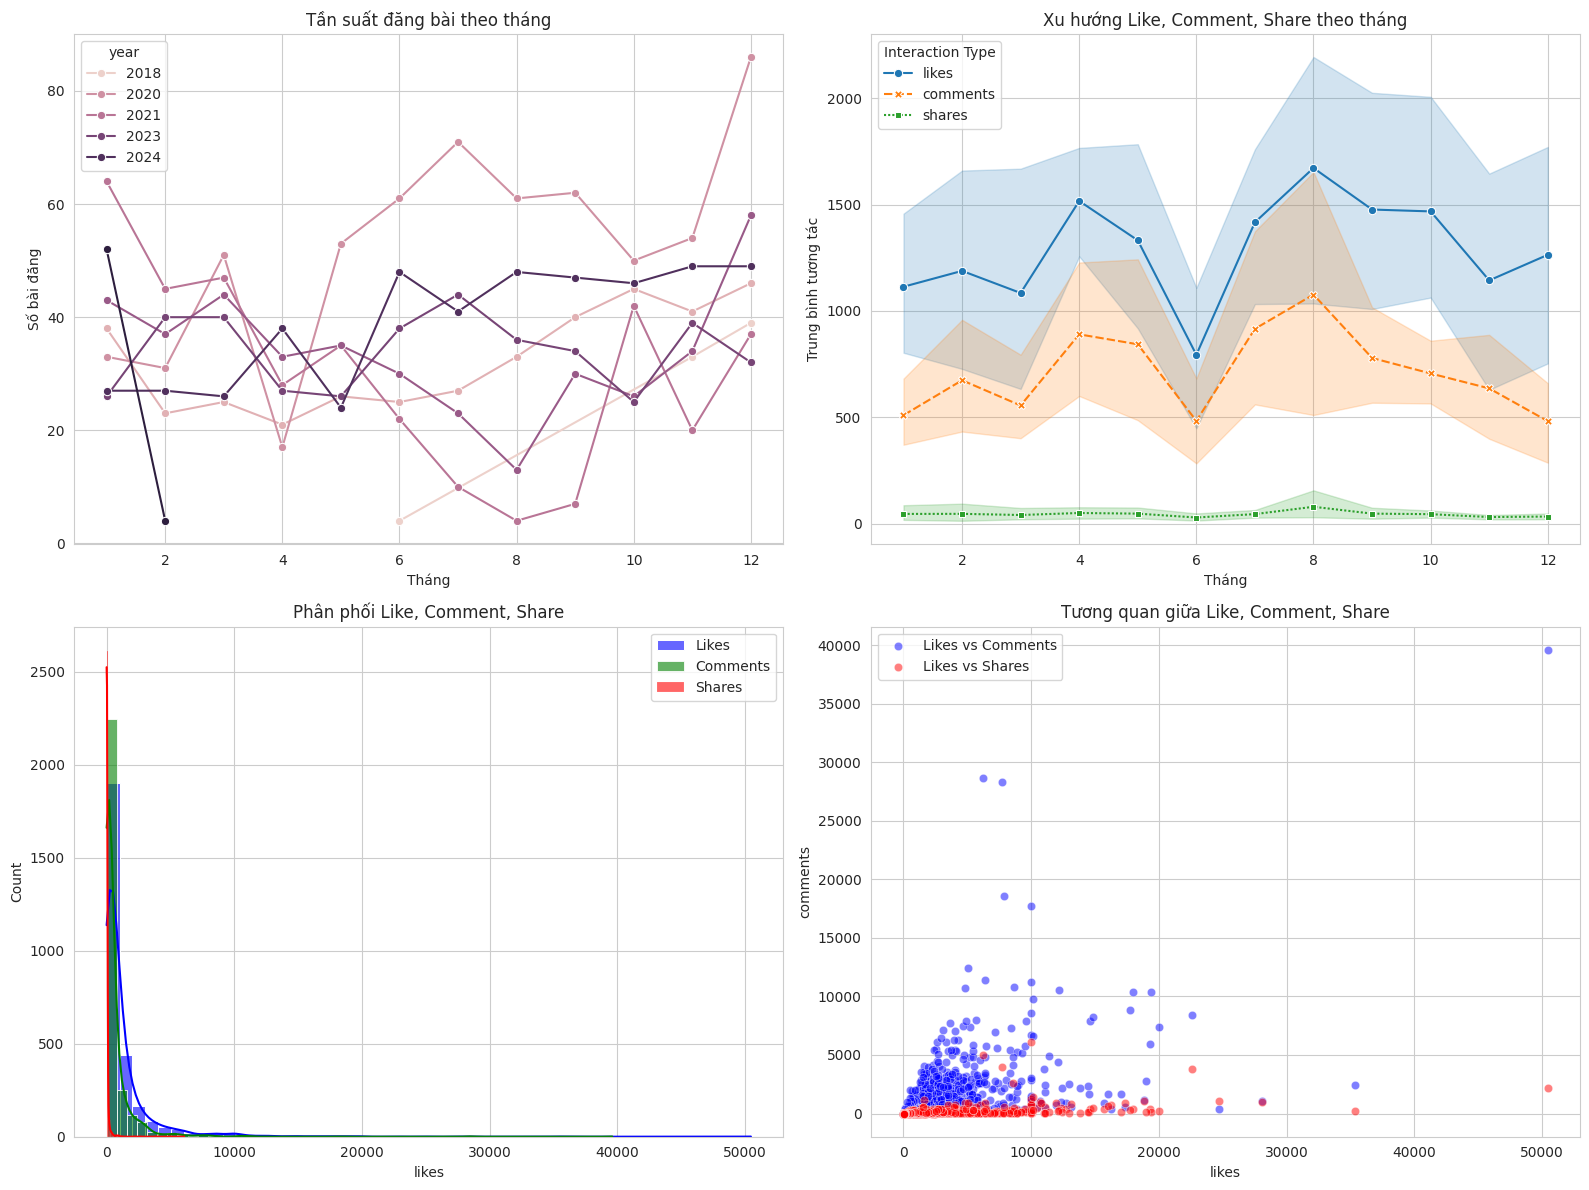

In [ ]:
import seaborn as sns

# Thiết lập kiểu hiển thị đẹp hơn
sns.set_style("whitegrid")

# Tạo figure với nhiều biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Biểu đồ 1: Tần suất đăng bài theo thời gian
sns.lineplot(data=post_frequency, x='month', y='post_count', hue='year', marker='o', ax=axes[0, 0])
axes[0, 0].set_title("Tần suất đăng bài theo tháng")
axes[0, 0].set_ylabel("Số bài đăng")
axes[0, 0].set_xlabel("Tháng")

# Biểu đồ 2: Xu hướng Like, Comment, Share theo thời gian
# Melt the DataFrame to combine likes, comments, and shares into a single column for a single lineplot call
interaction_stats_melted = pd.melt(interaction_stats, id_vars=['year', 'month'],
                                    value_vars=['likes', 'comments', 'shares'],
                                    var_name='Interaction Type', value_name='Average Interaction')

sns.lineplot(data=interaction_stats_melted, x='month', y='Average Interaction',
             hue='Interaction Type', style='Interaction Type', markers=True, ax=axes[0, 1])

axes[0, 1].set_title("Xu hướng Like, Comment, Share theo tháng")
axes[0, 1].set_ylabel("Trung bình tương tác")
axes[0, 1].set_xlabel("Tháng")

# Biểu đồ 3: Phân phối Like, Comment, Share (Histogram)
sns.histplot(df['likes'], bins=50, kde=True, color='blue', ax=axes[1, 0], label='Likes', alpha=0.6)
sns.histplot(df['comments'], bins=50, kde=True, color='green', ax=axes[1, 0], label='Comments', alpha=0.6)
sns.histplot(df['shares'], bins=50, kde=True, color='red', ax=axes[1, 0], label='Shares', alpha=0.6)
axes[1, 0].set_title("Phân phối Like, Comment, Share")
axes[1, 0].legend()

# Biểu đồ 4: Tương quan giữa các chỉ số tương tác
sns.scatterplot(data=df, x='likes', y='comments', ax=axes[1, 1], alpha=0.5, label='Likes vs Comments', color='blue')
sns.scatterplot(data=df, x='likes', y='shares', ax=axes[1, 1], alpha=0.5, label='Likes vs Shares', color='red')
axes[1, 1].set_title("Tương quan giữa Like, Comment, Share")

plt.tight_layout()
plt.show()

<ipython-input-32-d178c6d3e513>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_post_count, x='month', y='post_count', palette='Blues_r')


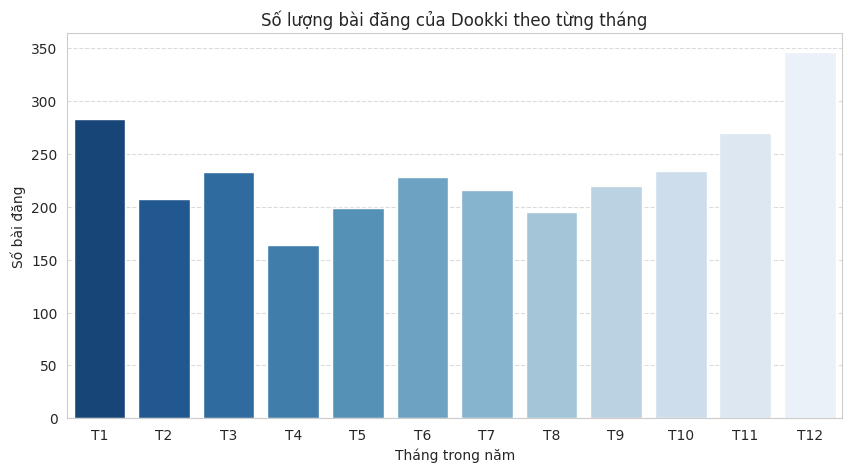

In [ ]:
# Đếm số bài đăng theo từng tháng trong năm
monthly_post_count = df.groupby('month').size().reset_index(name='post_count')

# Vẽ biểu đồ số lượng bài đăng theo tháng
plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_post_count, x='month', y='post_count', palette='Blues_r')

plt.xlabel("Tháng trong năm")
plt.ylabel("Số bài đăng")
plt.title("Số lượng bài đăng của Dookki theo từng tháng")
plt.xticks(range(0, 12), [f'T{i+1}' for i in range(12)])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
